<a href="https://colab.research.google.com/github/zencod-646/VOWEL_A/blob/main/DECISION%20TREE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# # =====================================
# # UNZIP DATASET
# # =====================================

# import zipfile

# zip_path = "/content/modulated vowels.zip"

# extract_path = "/content"

# with zipfile.ZipFile(
#     zip_path,
#     'r'
# ) as zip_ref:

#     zip_ref.extractall(
#         extract_path
#     )

# print("Dataset extracted")

In [ ]:

# =====================================
# DATASET PATH
# =====================================

dataset_path = "/content/modulated vowels"

In [ ]:
# =====================================
# HYBRID FEATURE EXTRACTION
# =====================================

def extract_hybrid_features(filepath):

    audio, sr = librosa.load(
        filepath,
        sr=16000
    )

    features = []

    # -----------------------
    # MFCC
    # -----------------------

    mfcc = librosa.feature.mfcc(

        y=audio,

        sr=sr,

        n_mfcc=13
    )

    features.extend(
        np.mean(
            mfcc,
            axis=1
        )
    )

    features.extend(
        np.std(
            mfcc,
            axis=1
        )
    )

    # -----------------------
    # Spectral
    # -----------------------

    features.append(
        np.mean(
            librosa.feature.zero_crossing_rate(
                audio
            )
        )
    )

    features.append(
        np.mean(
            librosa.feature.rms(
                y=audio
            )
        )
    )

    features.append(
        np.mean(
            librosa.feature.spectral_centroid(
                y=audio,
                sr=sr
            )
        )
    )

    features.append(
        np.mean(
            librosa.feature.spectral_bandwidth(
                y=audio,
                sr=sr
            )
        )
    )

    features.append(
        np.mean(
            librosa.feature.spectral_rolloff(
                y=audio,
                sr=sr
            )
        )
    )

    # -----------------------
    # Chroma
    # -----------------------

    chroma = librosa.feature.chroma_stft(

        y=audio,

        sr=sr
    )

    features.extend(
        np.mean(
            chroma,
            axis=1
        )
    )

    # -----------------------
    # Mel
    # -----------------------

    mel = librosa.feature.melspectrogram(

        y=audio,

        sr=sr,

        n_mels=20
    )

    features.extend(
        np.mean(
            mel,
            axis=1
        )
    )

    return np.array(
        features
    )

***MAX DEPTH = 2***

In [3]:

# =====================================
# BUILD DATASET FOR VOWEL A
# =====================================

X = []

y = []

groups = []

for class_name in [

    "hc",

    "pd"
]:

    vowel_folder = os.path.join(

        dataset_path,

        class_name,

        "A"
    )

    for file in os.listdir(
        vowel_folder
    ):

        if file.endswith(
            ".wav"
        ):

            filepath = os.path.join(

                vowel_folder,

                file
            )

            feat = extract_hybrid_features(
                filepath
            )

            X.append(
                feat
            )

            y.append(

                0 if class_name=="hc"

                else 1
            )

            groups.append(
                file[10:14]
            )

X = np.array(X)

y = np.array(y)

groups = np.array(groups)

print(
    "Feature shape:",
    X.shape
)

print(
    "Samples:",
    len(X)
)



Feature shape: (100, 63)
Samples: 100


***MAX DEPTH = 2***

In [4]:
# =====================================
# DECISION TREE
# =====================================

gkf = GroupKFold(
    n_splits=5
)

acc_scores = []

prec_scores = []

rec_scores = []

f1_scores = []

for train_idx, test_idx in gkf.split(

    X,

    y,

    groups
):

    X_train = X[
        train_idx
    ]

    X_test = X[
        test_idx
    ]

    y_train = y[
        train_idx
    ]

    y_test = y[
        test_idx
    ]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        X_train
    )

    X_test = scaler.transform(
        X_test
    )

    model = DecisionTreeClassifier(

        max_depth=2,

        random_state=42
    )

    model.fit(

        X_train,

        y_train
    )

    pred = model.predict(
        X_test
    )

    acc_scores.append(

        accuracy_score(
            y_test,
            pred
        )
    )

    prec_scores.append(

        precision_score(
            y_test,
            pred
        )
    )

    rec_scores.append(

        recall_score(
            y_test,
            pred
        )
    )

    f1_scores.append(

        f1_score(
            y_test,
            pred
        )
    )

print()

print(
    "Accuracy:",
    np.mean(acc_scores)
)

print(
    "Precision:",
    np.mean(prec_scores)
)

print(
    "Recall:",
    np.mean(rec_scores)
)

print(
    "F1 Score:",
    np.mean(f1_scores)
)


Accuracy: 0.65
Precision: 0.6394871794871795
Recall: 0.6810101010101011
F1 Score: 0.645286734623119


  max_depth  Accuracy  Precision    Recall        F1
0         2      0.65   0.639487  0.681010  0.645287
1         3      0.65   0.627179  0.765051  0.685112
2         5      0.60   0.596667  0.600606  0.595811
3        10      0.62   0.616667  0.622828  0.615556
4        15      0.62   0.616667  0.622828  0.615556
5        17      0.62   0.616667  0.622828  0.615556
6        20      0.62   0.616667  0.622828  0.615556
7      None      0.62   0.616667  0.622828  0.615556


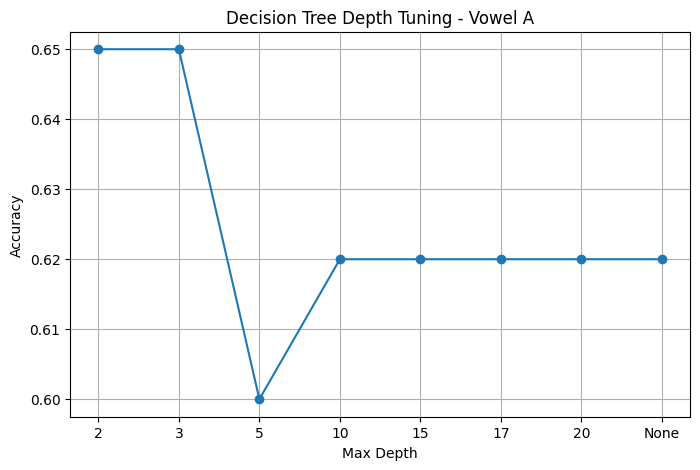

In [9]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

depths = [2, 3, 5, 10, 15,17,20, None]

results = []

for depth in depths:

    gkf = GroupKFold(
        n_splits=5
    )

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    for train_idx, test_idx in gkf.split(
        X,
        y,
        groups
    ):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(
            X_train
        )

        X_test = scaler.transform(
            X_test
        )

        model = DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        )

        model.fit(
            X_train,
            y_train
        )

        pred = model.predict(
            X_test
        )

        acc_scores.append(
            accuracy_score(
                y_test,
                pred
            )
        )

        prec_scores.append(
            precision_score(
                y_test,
                pred,
                zero_division=0
            )
        )

        rec_scores.append(
            recall_score(
                y_test,
                pred
            )
        )

        f1_scores.append(
            f1_score(
                y_test,
                pred
            )
        )

    results.append([
        str(depth),
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "max_depth",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(results_df)

# -----------------------
# Accuracy Graph
# -----------------------

plt.figure(figsize=(8,5))

plt.plot(
    results_df["max_depth"],
    results_df["Accuracy"],
    marker="o"
)

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")

plt.title(
    "Decision Tree Depth Tuning - Vowel A"
)

plt.grid(True)

plt.show()

***TUNING MIN. SAMPLES LEAF***

   min_samples_leaf  Accuracy  Precision    Recall        F1
0                 1      0.65   0.627179  0.765051  0.685112
1                 2      0.65   0.631375  0.742828  0.679657
2                 4      0.66   0.640350  0.742828  0.685191
3                 8      0.65   0.633427  0.722828  0.671594
4                10      0.66   0.632821  0.755152  0.685440
5                12      0.67   0.652564  0.758788  0.698225
6                14      0.69   0.685043  0.738788  0.706463
7                16      0.68   0.687094  0.658788  0.658400
8                18      0.70   0.723077  0.638788  0.667843
9                20      0.72   0.763333  0.638788  0.679355


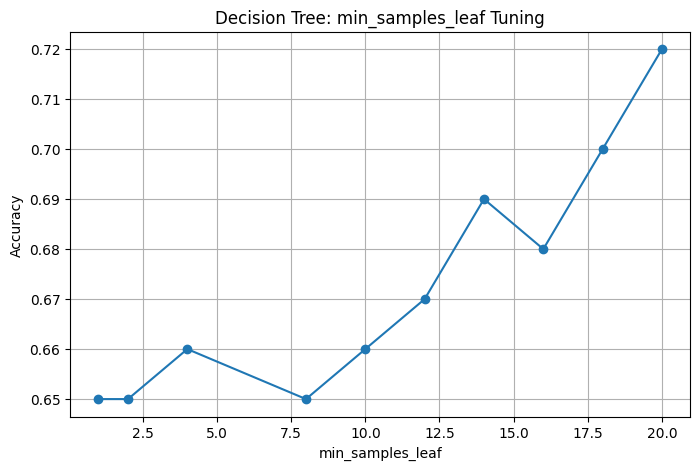

In [10]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BEST_DEPTH = 3   # replace with your best depth

leaf_values = [1, 2, 4, 8, 10,12,14,16,18,20]

results = []

for leaf in leaf_values:

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    gkf = GroupKFold(n_splits=5)

    for train_idx, test_idx in gkf.split(X, y, groups):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = DecisionTreeClassifier(
            max_depth=BEST_DEPTH,
            min_samples_leaf=leaf,
            random_state=42
        )

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        acc_scores.append(accuracy_score(y_test, pred))
        prec_scores.append(precision_score(y_test, pred, zero_division=0))
        rec_scores.append(recall_score(y_test, pred))
        f1_scores.append(f1_score(y_test, pred))

    results.append([
        leaf,
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

df = pd.DataFrame(
    results,
    columns=[
        "min_samples_leaf",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(df)

plt.figure(figsize=(8,5))
plt.plot(df["min_samples_leaf"], df["Accuracy"], marker="o")
plt.xlabel("min_samples_leaf")
plt.ylabel("Accuracy")
plt.title("Decision Tree: min_samples_leaf Tuning")
plt.grid(True)
plt.show()